<a href="https://colab.research.google.com/github/mzaib1012/Grid-Tied-Three-Phase-Inverter-with-Space-Vector-PWM-SVPWM-/blob/main/notebooks/svpwm_inverter_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. System Parameters & Time Discretization ---
f_grid = 50.0          # Grid frequency (Hz)
w_grid = 2 * np.pi * f_grid  # Angular velocity (rad/s)
f_sw = 10e3            # Switching frequency (10 kHz)
T_s = 1.0 / f_sw       # Sampling period (100 µs)
V_dc = 800.0           # DC Bus Voltage (V)

# Time vector for 1 full grid cycle (20 milliseconds)
t_vector = np.linspace(0, 0.02, 200)

# --- 2. Mathematical Coordinate Transformations ---
def clarke_transform(v_a, v_b, v_c):
    """Converts stationary abc components to stationary alpha-beta frame."""
    v_alpha = (2.0 / 3.0) * (v_a - 0.5 * v_b - 0.5 * v_c)
    v_beta = (2.0 / 3.0) * ((np.sqrt(3.0) / 2.0) * v_b - (np.sqrt(3.0) / 2.0) * v_c)
    return v_alpha, v_beta

def park_transform(v_alpha, v_beta, theta):
    """Converts stationary alpha-beta frame to synchronously rotating d-q frame."""
    v_d = v_alpha * np.cos(theta) + v_beta * np.sin(theta)
    v_q = -v_alpha * np.sin(theta) + v_beta * np.cos(theta)
    return v_d, v_q

print("Transformation matrices initialized successfully.")

Transformation matrices initialized successfully.


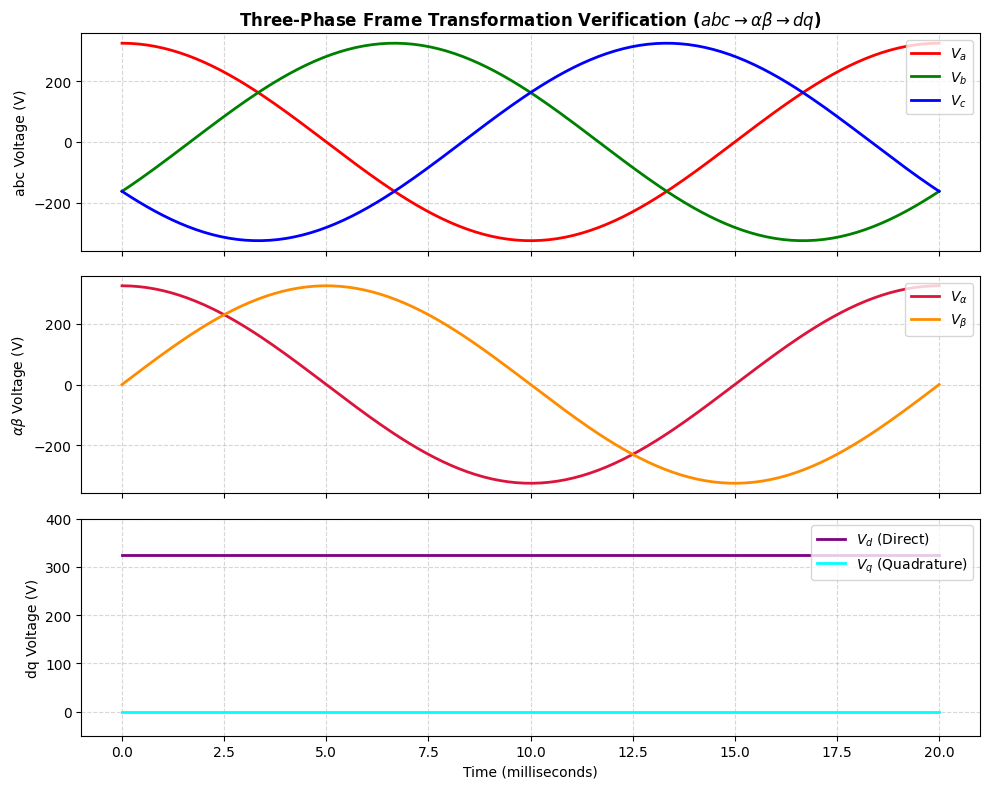

In [2]:
# --- 1. Generate Balanced 3-Phase Sinusoidal Signals ---
V_peak = 325.0  # Peak phase voltage amplitude (V)

v_a = V_peak * np.cos(w_grid * t_vector)
v_b = V_peak * np.cos(w_grid * t_vector - 2.0 * np.pi / 3.0)
v_c = V_peak * np.cos(w_grid * t_vector + 2.0 * np.pi / 3.0)

# --- 2. Arrays to Store Transformed Frames ---
v_alpha_hist = []
v_beta_hist = []
v_d_hist = []
v_q_hist = []

# --- 3. Process Loops Over Time ---
for i in range(len(t_vector)):
    theta = w_grid * t_vector[i]  # Instantaneous grid angle

    # Run Clarke
    v_alpha, v_beta = clarke_transform(v_a[i], v_b[i], v_c[i])
    v_alpha_hist.append(v_alpha)
    v_beta_hist.append(v_beta)

    # Run Park
    v_d, v_q = park_transform(v_alpha, v_beta, theta)
    v_d_hist.append(v_d)
    v_q_hist.append(v_q)

# --- 4. Plot Coordinate Transformation Results ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Plot 1: ABC Stationary Frame
ax1.plot(t_vector * 1000, v_a, 'r', lw=2, label='$V_a$')
ax1.plot(t_vector * 1000, v_b, 'g', lw=2, label='$V_b$')
ax1.plot(t_vector * 1000, v_c, 'b', lw=2, label='$V_c$')
ax1.set_ylabel('abc Voltage (V)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')
ax1.set_title('Three-Phase Frame Transformation Verification ($abc \\rightarrow \\alpha\\beta \\rightarrow dq$)', fontsize=12, weight='bold')

# Plot 2: Alpha-Beta Stationary Orthogonal Frame
ax2.plot(t_vector * 1000, v_alpha_hist, 'crimson', lw=2, label='$V_\\alpha$')
ax2.plot(t_vector * 1000, v_beta_hist, 'darkorange', lw=2, label='$V_\\beta$')
ax2.set_ylabel('$\\alpha\\beta$ Voltage (V)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right')

# Plot 3: DQ Synchronously Rotating Frame
ax3.plot(t_vector * 1000, v_d_hist, 'purple', lw=2, label='$V_d$ (Direct)')
ax3.plot(t_vector * 1000, v_q_hist, 'cyan', lw=2, label='$V_q$ (Quadrature)')
ax3.set_xlabel('Time (milliseconds)')
ax3.set_ylabel('dq Voltage (V)')
ax3.set_ylim(-50, 400)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [3]:
def identify_sector(v_alpha, v_beta):
    """
    Identifies the instantaneous sector (1 to 6) of the voltage space vector
    based on its position in the stationary alpha-beta orthogonal plane.
    """
    # Calculate the angle of the space vector in radians (-pi to pi)
    angle = np.arctan2(v_beta, v_alpha)

    # Map the angle from [-pi, pi] to a continuous [0, 2*pi] range
    if angle < 0:
        angle += 2 * np.pi

    # Convert angle to degrees to make sector slicing straightforward
    angle_deg = np.degrees(angle)

    # Slice the plane into six 60-degree windows
    if 0 <= angle_deg < 60:
        return 1
    elif 60 <= angle_deg < 120:
        return 2
    elif 120 <= angle_deg < 180:
        return 3
    elif 180 <= angle_deg < 240:
        return 4
    elif 240 <= angle_deg < 300:
        return 5
    else:
        return 6

# Quick programmatic test to verify sector tracking over time
sectors_tracked = [identify_sector(v_alpha_hist[i], v_beta_hist[i]) for i in range(len(t_vector))]
print("Sector identification function defined and verified successfully!")
print(f"Sample Sector sequence during the first few time steps: {sectors_tracked[:15]}")

Sector identification function defined and verified successfully!
Sample Sector sequence during the first few time steps: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
def compute_dwell_times(v_alpha, v_beta, sector, T_s, V_dc):
    """
    Computes the high-frequency gating dwell times (T1, T2, T0)
    for the active and zero states based on sector location.
    """
    # 1. Calculate the magnitude and absolute spatial angle of V_ref
    V_ref_mag = np.sqrt(v_alpha**2 + v_beta**2)
    angle = np.arctan2(v_beta, v_alpha)
    if angle < 0:
        angle += 2 * np.pi

    # 2. Shift the absolute angle to find the localized sector angle theta_z (0 to 60 deg)
    sector_angle = angle - (sector - 1) * (np.pi / 3.0)

    # 3. Apply Space Vector projection laws to isolate T1 and T2
    # Scaling factor based on standard linear-range modulation indices
    k = np.sqrt(3) * T_s * V_ref_mag / V_dc

    T_1 = k * np.sin(np.pi / 3.0 - sector_angle)
    T_2 = k * np.sin(sector_angle)
    T_0 = T_s - T_1 - T_2

    # Structural over-modulation guard rail
    if T_0 < 0:
        # Normalize timings to prevent mathematical saturation distortion
        total_T = T_1 + T_2
        T_1 = (T_1 / total_T) * T_s
        T_2 = (T_2 / total_T) * T_s
        T_0 = 0.0

    return T_1, T_2, T_0

print("Dwell time projection calculus initialized successfully.")

Dwell time projection calculus initialized successfully.


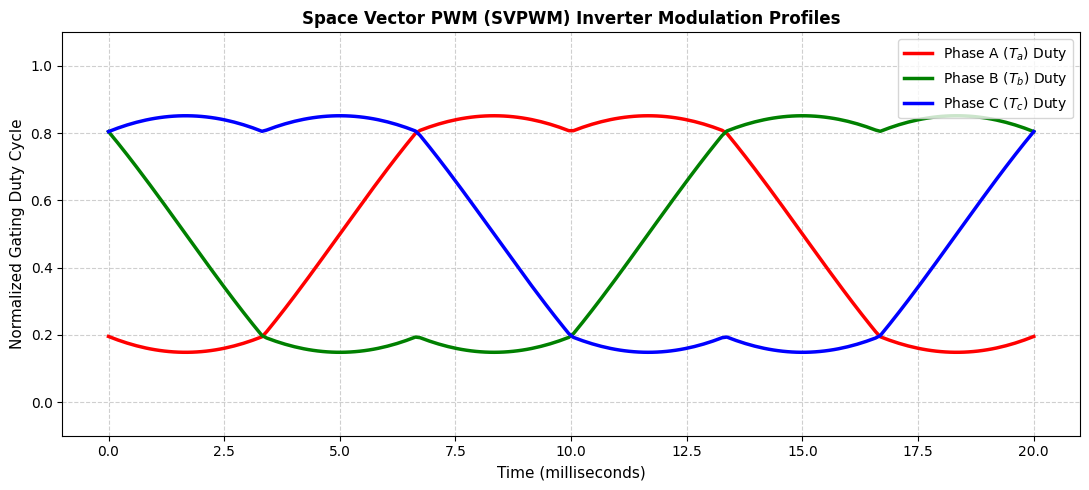

SVPWM transient waveform rendering complete.


In [5]:
# --- 1. Initialize Logging Containers for Modulation Signals ---
ta_history = []
tb_history = []
tc_history = []

# --- 2. Run the Inverter Simulation Loop Across Time ---
for i in range(len(t_vector)):
    # Retrieve current stationary voltage vectors from history
    v_alpha = v_alpha_hist[i]
    v_beta = v_beta_hist[i]

    # Isolate active sector
    sector = identify_sector(v_alpha, v_beta)

    # Calculate dwell times
    T_1, T_2, T_0 = compute_dwell_times(v_alpha, v_beta, sector, T_s, V_dc)

    # --- 3. Symmetric 7-Segment PWM Duty Allocation ---
    # Map timing distributions based on the active sector layout
    if sector == 1:
        t_a = 0.5 * T_0
        t_b = 0.5 * T_0 + T_1
        t_c = 0.5 * T_0 + T_1 + T_2
    elif sector == 2:
        t_a = 0.5 * T_0 + T_2
        t_b = 0.5 * T_0
        t_c = 0.5 * T_0 + T_1 + T_2
    elif sector == 3:
        t_a = 0.5 * T_0 + T_1 + T_2
        t_b = 0.5 * T_0
        t_c = 0.5 * T_0 + T_1
    elif sector == 4:
        t_a = 0.5 * T_0 + T_1 + T_2
        t_b = 0.5 * T_0 + T_2
        t_c = 0.5 * T_0
    elif sector == 5:
        t_a = 0.5 * T_0 + T_1
        t_b = 0.5 * T_0 + T_1 + T_2
        t_c = 0.5 * T_0
    elif sector == 6:
        t_a = 0.5 * T_0
        t_b = 0.5 * T_0 + T_1 + T_2
        t_c = 0.5 * T_0 + T_2

    # Normalize to duty cycle values (0.0 to 1.0) for visualization
    ta_history.append(t_a / T_s)
    tb_history.append(t_b / T_s)
    tc_history.append(t_c / T_s)

# --- 4. Plot the Space Vector PWM Modulation Profiles ---
plt.figure(figsize=(11, 5))
plt.plot(t_vector * 1000, ta_history, 'r', lw=2.5, label='Phase A ($T_a$) Duty')
plt.plot(t_vector * 1000, tb_history, 'g', lw=2.5, label='Phase B ($T_b$) Duty')
plt.plot(t_vector * 1000, tc_history, 'b', lw=2.5, label='Phase C ($T_c$) Duty')

plt.title('Space Vector PWM (SVPWM) Inverter Modulation Profiles', fontsize=12, weight='bold')
plt.xlabel('Time (milliseconds)', fontsize=11)
plt.ylabel('Normalized Gating Duty Cycle', fontsize=11)
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('svpwm_modulation_waveforms.png', dpi=300)
plt.show()

print("SVPWM transient waveform rendering complete.")

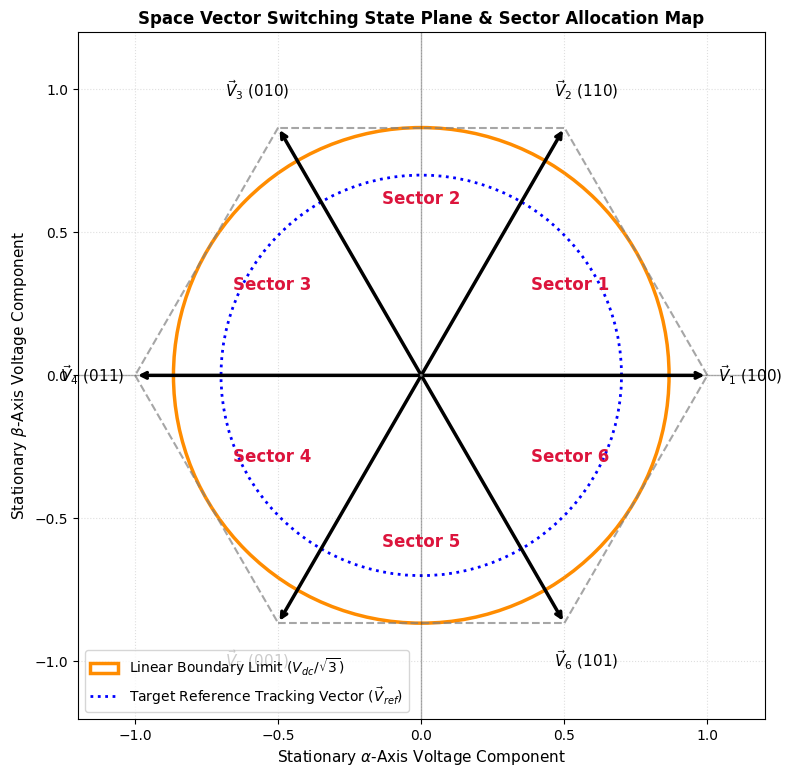

SVPWM switching trajectory plane generated successfully.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Create a Vector Plane Map Showing the Active Sectors ---
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

# 1. Define Hexagram Vertices for the 6 Active State Vectors (Note the raw 'r' prefix added below)
angles_deg = [0, 60, 120, 180, 240, 300]
angles_rad = np.radians(angles_deg)
labels = [r'$\vec{V}_1\ (100)$', r'$\vec{V}_2\ (110)$', r'$\vec{V}_3\ (010)$',
          r'$\vec{V}_4\ (011)$', r'$\vec{V}_5\ (001)$', r'$\vec{V}_6\ (101)$']

# 2. Draw Hexagon Boundary Lines and Vector Arrows
for i in range(6):
    x_start, y_start = 0, 0
    x_end, y_end = np.cos(angles_rad[i]), np.sin(angles_rad[i])
    x_next, y_next = np.cos(angles_rad[(i+1)%6]), np.sin(angles_rad[(i+1)%6])

    # Draw vector arrows from origin
    ax.annotate('', xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle="->", color='black', lw=2.5))
    ax.text(x_end*1.15, y_end*1.15, labels[i], fontsize=11, weight='bold', ha='center', va='center')

    # Draw sector outer boundary walls
    ax.plot([x_end, x_next], [y_end, y_next], color='gray', linestyle='--', alpha=0.7)

# 3. Label Sectors 1 through 6 Centrally
sector_centers = np.radians([30, 90, 150, 210, 270, 330])
for s in range(6):
    ax.text(0.6*np.cos(sector_centers[s]), 0.6*np.sin(sector_centers[s]),
            f'Sector {s+1}', color='crimson', fontsize=12, weight='bold', ha='center')

# 4. Draw the Maximum Linear Modulation Inscribing Circle (Note the raw 'r' prefix)
circle = patches.Circle((0, 0), np.sqrt(3)/2, edgecolor='darkorange', facecolor='none', lw=2.5,
                       linestyle='-', label=r'Linear Boundary Limit ($\mathit{V}_{dc}/\sqrt{3}$)')
ax.add_patch(circle)

# 5. Overlay an Ideal Rotating Reference Path Trace (Note the raw 'r' prefix)
theta_trace = np.linspace(0, 2*np.pi, 100)
ax.plot(0.7*np.cos(theta_trace), 0.7*np.sin(theta_trace), color='blue', lw=2,
        linestyle=':', label=r'Target Reference Tracking Vector ($\vec{V}_{ref}$)')

# Format Plot Space
ax.axhline(0, color='black', lw=1, alpha=0.3)
ax.axvline(0, color='black', lw=1, alpha=0.3)
ax.set_title('Space Vector Switching State Plane & Sector Allocation Map', fontsize=12, weight='bold')
ax.set_xlabel(r'Stationary $\alpha$-Axis Voltage Component', fontsize=11)
ax.set_ylabel(r'Stationary $\beta$-Axis Voltage Component', fontsize=11)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('svpwm_vector_sectors.png', dpi=300)
plt.show()
print("SVPWM switching trajectory plane generated successfully.")